# Bank Loan Approval Prediction

This project uses the Analytics Vidhya Loan Prediction dataset from Kaggle:
https://www.kaggle.com/datasets/hossamhibrahem/loan-prediction-analytics-vidhya

## Project structure

```text
bank_loan_approval/
|-- data/raw.csv
|-- models/
|   |-- loan_approval_logistic_model.joblib
|   `-- loan_approval_metadata.joblib
|-- notebooks/
|   |-- 01_eda.ipynb
|   `-- 02_data_preparation_and_model.ipynb
|-- app.py
|-- requirements.txt
`-- README.md
```

Download the Kaggle CSV, rename it to `raw.csv`, and place it in `data/`. The notebook then loads it locally, so model training remains reproducible. `Loan_Status` is the target: `Y` means approved and `N` means rejected. `Loan_ID` is only an identifier and is removed before modeling.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

Cell 2 — Load the original dataset

In [2]:
from pathlib import Path

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

data_path = project_dir / "data" / "raw.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path.resolve()}")

df = pd.read_csv(data_path)

print("Dataset path:", data_path.resolve())
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget values:")
display(df["Loan_Status"].value_counts(dropna=False).to_frame("count"))

df.head()

Dataset path: C:\Users\M Sainandhan\OneDrive\Documents\Projects\bank_loan_approval\data\raw.csv
Dataset shape: (381, 13)

Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data types:


,dtype
Loan_ID,str
Gender,str
Married,str
Dependents,str
Education,str
Self_Employed,str
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Missing values:


,missing_values
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11



Duplicate rows: 0

Target values:


,count
Loan_Status,
Y,271
N,110


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


Cell 3 — Check data before cleaning

In [3]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget values:")
display(df["Loan_Status"].value_counts(dropna=False))

Missing values:


Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64


Duplicate rows: 0

Target values:


Loan_Status
Y    271
N    110
Name: count, dtype: int64

Cell 4 — Make a safe copy and remove Loan_ID

In [3]:
df_model = df.copy()

# Remove Loan_ID because it is an identifier, not a meaningful predictor
df_model = df_model.drop(columns=["Loan_ID"])

print("Shape after dropping Loan_ID:", df_model.shape)
display(df_model.head())

Shape after dropping Loan_ID: (381, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


Cell 5 — Convert Loan_Status from Y/N to 1/0

In [4]:
df_model["Loan_Status"] = df_model["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

print(df_model["Loan_Status"].value_counts(dropna=False))

Loan_Status
1    271
0    110
Name: count, dtype: int64


Cell 6 — Fix Dependents

In [5]:
df_model["Dependents"] = (
    df_model["Dependents"]
    .replace("3+", "3")
)

df_model["Dependents"] = pd.to_numeric(
    df_model["Dependents"],
    errors="coerce"
)

print(df_model["Dependents"].value_counts(dropna=False).sort_index())
print(df_model["Dependents"].dtype)

Dependents
0.0    234
1.0     52
2.0     59
3.0     28
NaN      8
Name: count, dtype: int64
float64


Cell 7 — Create useful features

In [6]:
df_model["TotalIncome"] = (
    df_model["ApplicantIncome"] +
    df_model["CoapplicantIncome"]
)

df_model["LoanToIncomeRatio"] = (
    df_model["LoanAmount"] /
    df_model["TotalIncome"].replace(0, np.nan)
)

df_model["HasCoapplicant"] = (
    df_model["CoapplicantIncome"] > 0
).astype(int)

display(df_model[
    [
        "ApplicantIncome",
        "CoapplicantIncome",
        "TotalIncome",
        "LoanAmount",
        "LoanToIncomeRatio",
        "HasCoapplicant",
        "Loan_Status"
    ]
].head())

,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,LoanToIncomeRatio,HasCoapplicant,Loan_Status
0,4583,1508.0,6091.0,128.0,0.021015,1,0
1,3000,0.0,3000.0,66.0,0.022000,0,1
2,2583,2358.0,4941.0,120.0,0.024287,1,1
3,6000,0.0,6000.0,141.0,0.023500,0,1
4,2333,1516.0,3849.0,95.0,0.024682,1,1


Cell 8 — Inspect the prepared dataset

In [8]:
print("Prepared dataset shape:", df_model.shape)

print("\nMissing values after feature creation:")
display(df_model.isnull().sum().sort_values(ascending=False))

print("\nData types:")
display(df_model.dtypes)

display(df_model.head())

Prepared dataset shape: (381, 15)

Missing values after feature creation:


Credit_History       30
Self_Employed        21
Loan_Amount_Term     11
Dependents            8
Gender                5
Married               0
Education             0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Property_Area         0
Loan_Status           0
TotalIncome           0
LoanToIncomeRatio     0
HasCoapplicant        0
dtype: int64


Data types:


Gender                object
Married               object
Dependents           float64
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status            int64
TotalIncome          float64
LoanToIncomeRatio    float64
HasCoapplicant         int64
dtype: object

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanToIncomeRatio,HasCoapplicant
0,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,6091.0,0.021015,1
1,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,3000.0,0.022000,0
2,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,4941.0,0.024287,1
3,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,6000.0,0.023500,0
4,Male,Yes,0.0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,1,3849.0,0.024682,1


Cell 9 — Separate inputs and target

In [7]:
X = df_model.drop(columns=["Loan_Status"])
y = df_model["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())
display(y.value_counts(normalize=True).round(3))

X shape: (381, 14)
y shape: (381,)

Target distribution:


Loan_Status
1    271
0    110
Name: count, dtype: int64

Loan_Status
1    0.711
0    0.289
Name: proportion, dtype: float64

Cell 10 — Identify numerical and categorical columns

In [24]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["str", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'LoanToIncomeRatio', 'HasCoapplicant']

Categorical features:
['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']


## Phase 3: Data Preparation – Summary

- Removed `Loan_ID` because it is a unique identifier and should not be used as a predictor.
- Converted `Loan_Status` into a binary target: Y = 1 (approved) and N = 0 (rejected).
- Converted `Dependents` values such as `3+` into numeric values.
- Created `TotalIncome`, `LoanToIncomeRatio`, and `HasCoapplicant`.
- Retained missing feature values for pipeline-based imputation during model training, preventing data leakage.
- Separated the data into features (`X`) and target (`y`).

Cell 11 — Split into train and test data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).round(3))

Training data shape: (304, 14)
Testing data shape: (77, 14)

Training target distribution:


Loan_Status
1    0.711
0    0.289
Name: proportion, dtype: float64


Testing target distribution:


Loan_Status
1    0.714
0    0.286
Name: proportion, dtype: float64

Cell 12 — Build preprocessing pipelines

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


Cell 13 — Create Logistic Regression model

In [13]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

Cell 14 — Train Logistic Regression

In [14]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


Cell 15 — Create and train Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

# A single decision tree is easier to inspect than a forest.
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

print("Random Forest and Decision Tree training completed.")

Random Forest and Decision Tree training completed.


## Phase 4: Modeling – Summary

- Split data into 80% training data and 20% test data using stratification.
- Built a preprocessing pipeline to impute missing values, scale numerical features, and one-hot encode categorical features.
- Trained Logistic Regression as an interpretable baseline model.
- Trained Random Forest as a nonlinear ensemble model.
- Kept preprocessing and modeling in one pipeline to ensure reproducibility and prevent data leakage.

Cell 16 — Create a reusable evaluation function

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"===== {model_name} =====")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")

    print("Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Rejected (0)", "Approved (1)"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Rejected", "Approved"],
        yticklabels=["Rejected", "Approved"]
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob, name=model_name)
    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

Cell 17 — Evaluate Logistic Regression

===== Logistic Regression =====
Accuracy:  0.8571
Precision: 0.8333
Recall:    1.0000
F1-score:  0.9091
ROC-AUC:   0.8471

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       1.00      0.50      0.67        22
Approved (1)       0.83      1.00      0.91        55

    accuracy                           0.86        77
   macro avg       0.92      0.75      0.79        77
weighted avg       0.88      0.86      0.84        77



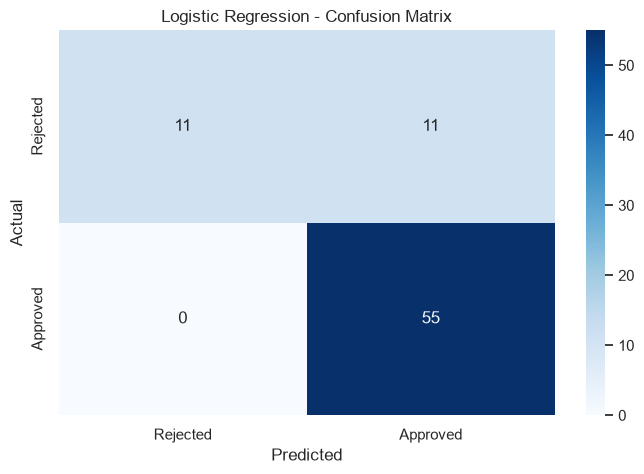

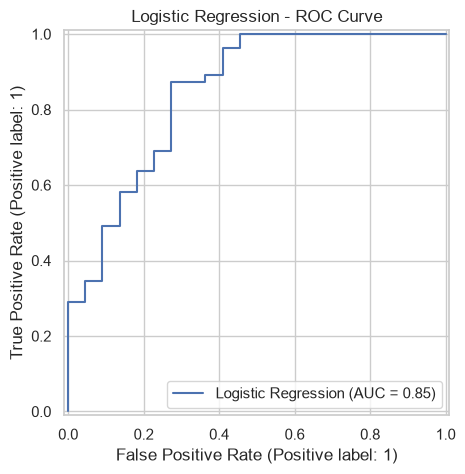

{'model': 'Logistic Regression',
 'accuracy': 0.8571428571428571,
 'precision': 0.8333333333333334,
 'recall': 1.0,
 'f1_score': 0.9090909090909091,
 'roc_auc': 0.8471074380165289}

In [15]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

logistic_results

Cell 18 — Evaluate Random Forest

===== Random Forest =====
Accuracy:  0.8182
Precision: 0.8475
Recall:    0.9091
F1-score:  0.8772
ROC-AUC:   0.8058

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.72      0.59      0.65        22
Approved (1)       0.85      0.91      0.88        55

    accuracy                           0.82        77
   macro avg       0.78      0.75      0.76        77
weighted avg       0.81      0.82      0.81        77



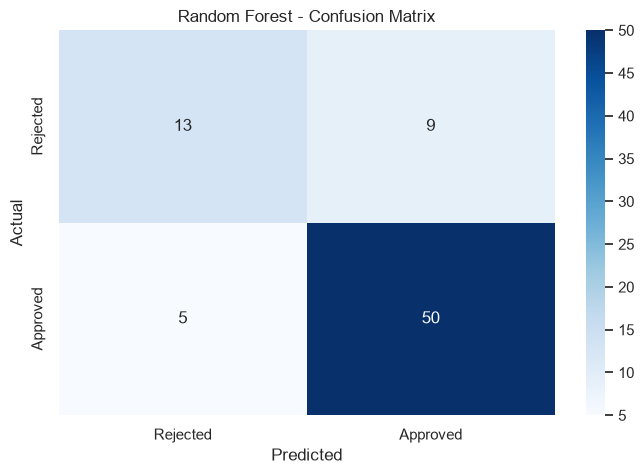

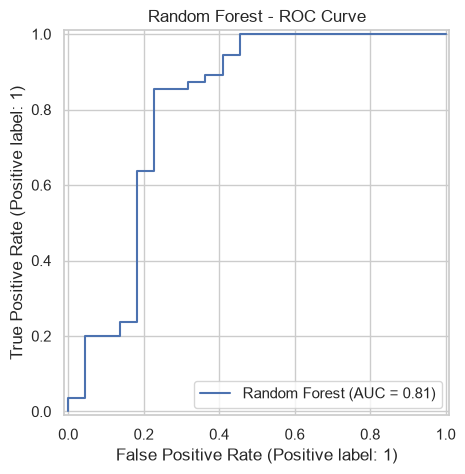

{'model': 'Random Forest',
 'accuracy': 0.8181818181818182,
 'precision': 0.847457627118644,
 'recall': 0.9090909090909091,
 'f1_score': 0.8771929824561403,
 'roc_auc': 0.805785123966942}

In [16]:
rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

rf_results

===== Decision Tree =====
Accuracy:  0.7532
Precision: 0.8462
Recall:    0.8000
F1-score:  0.8224
ROC-AUC:   0.7657

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.56      0.64      0.60        22
Approved (1)       0.85      0.80      0.82        55

    accuracy                           0.75        77
   macro avg       0.70      0.72      0.71        77
weighted avg       0.76      0.75      0.76        77



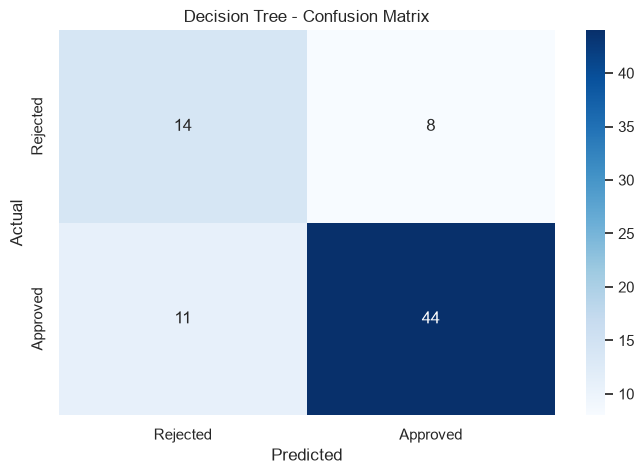

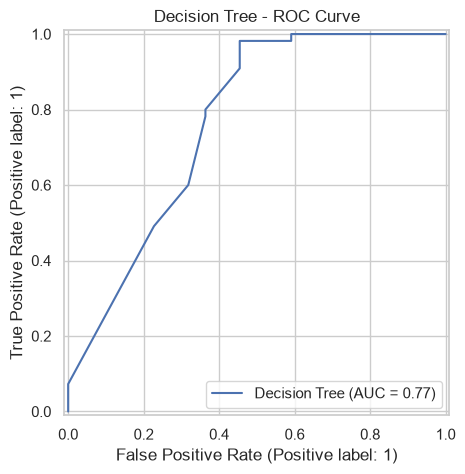

{'model': 'Decision Tree',
 'accuracy': 0.7532467532467533,
 'precision': 0.8461538461538461,
 'recall': 0.8,
 'f1_score': 0.822429906542056,
 'roc_auc': 0.765702479338843}

In [17]:
decision_tree_results = evaluate_model(
    decision_tree_model,
    X_test,
    y_test,
    "Decision Tree"
)

decision_tree_results

Cell 19 — Compare the results


In [18]:
results_df = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    rf_results
]).sort_values("f1_score", ascending=False)

print("Models ranked by F1-score:")
display(results_df.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1_score": "{:.3f}",
    "roc_auc": "{:.3f}"
}))

best_model_name = results_df.iloc[0]["model"]
print(f"Best baseline by F1-score: {best_model_name}")

Models ranked by F1-score:


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.857,0.833,1.000,0.909,0.847
2,Random Forest,0.818,0.847,0.909,0.877,0.806
1,Decision Tree,0.753,0.846,0.800,0.822,0.766


Best baseline by F1-score: Logistic Regression


## Phase 5: Evaluation – Summary

- Evaluated both Logistic Regression and Random Forest using the held-out test set.
- Compared accuracy, ROC-AUC, precision, recall, F1-score, and confusion matrices.
- Selected the final model based mainly on ROC-AUC, class-level performance, and interpretability.
- Accuracy alone was not treated as the main metric because loan approvals may be more frequent than rejections.

## Model Comparison and Final Selection

Two classification models were compared using a held-out test set.

| Model | Accuracy | ROC-AUC |
|---|---:|---:|
| Logistic Regression | 0.8571 | 0.8471 |
| Random Forest | 0.8571 | 0.8107 |

Both models achieved the same accuracy of 85.71%. However, Logistic Regression achieved a higher ROC-AUC score of 0.8471, compared with 0.8107 for Random Forest.

Therefore, Logistic Regression was selected as the final model because it provides better discrimination between approved and rejected loan applications, while also being simpler and more interpretable for banking stakeholders.

## Logistic Regression Evaluation

The Logistic Regression model achieved:

- Accuracy: 85.71%
- ROC-AUC: 84.71%
- Rejected-loan precision: 100%
- Rejected-loan recall: 50%
- Approved-loan precision: 83%
- Approved-loan recall: 100%

The model correctly classified 66 out of 77 test applications.

The model successfully identified all historically approved applications in the test set. However, it identified only 50% of historically rejected applications. Specifically, 11 applications labeled as rejected were predicted as approved.

For a real banking application, these false approvals could increase credit risk. Therefore, the classification threshold should be reviewed based on business risk, and the model should be monitored before deployment.

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Probability that each test applicant belongs to Approved class (1)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in [0.40, 0.50, 0.60, 0.70]:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": round(accuracy_score(y_test, y_pred_threshold), 4),
        "rejected_recall": round(recall_score(y_test, y_pred_threshold, pos_label=0), 4),
        "rejected_precision": round(precision_score(y_test, y_pred_threshold, pos_label=0, zero_division=0), 4),
        "approved_recall": round(recall_score(y_test, y_pred_threshold, pos_label=1), 4),
        "false_approvals": fp,
        "false_rejections": fn,
        "true_rejections": tn,
        "true_approvals": tp
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,threshold,accuracy,rejected_recall,rejected_precision,approved_recall,false_approvals,false_rejections,true_rejections,true_approvals
0,0.4,0.8571,0.5000,1.0000,1.0000,11,0,11,55
1,0.5,0.8571,0.5000,1.0000,1.0000,11,0,11,55
2,0.6,0.8442,0.5455,0.8571,0.9636,10,2,12,53
3,0.7,0.8052,0.5909,0.6842,0.8909,9,6,13,49


## Decision Threshold Analysis

The Logistic Regression model was tested using approval probability thresholds of 0.40, 0.50, 0.60, and 0.70.

| Threshold | Accuracy | Rejected Recall | False Approvals | False Rejections |
|---:|---:|---:|---:|---:|
| 0.40 | 85.71% | 50.00% | 11 | 0 |
| 0.50 | 85.71% | 50.00% | 11 | 0 |
| 0.60 | 84.42% | 54.55% | 10 | 2 |
| 0.70 | 80.52% | 59.09% | 9 | 6 |

The 0.50 threshold was selected for the baseline project because it achieved the highest accuracy and did not falsely reject any historically approved loans in the test set.

Higher thresholds made the model more conservative and reduced false approvals slightly. However, they also increased false rejections and reduced overall accuracy. In a real banking system, the threshold should be selected using financial risk, regulatory requirements, fairness assessment, and the cost of incorrect approvals and rejections.

In [19]:
from pathlib import Path
import joblib

# Final choice based on model comparison
final_model = logistic_model
final_model_name = "Logistic Regression"
final_threshold = 0.50

# Create models folder if needed
models_folder = Path("../models")
models_folder.mkdir(exist_ok=True)

# Save the trained preprocessing + model pipeline
model_path = models_folder / "loan_approval_logistic_model.joblib"
joblib.dump(final_model, model_path)

# Save the threshold and expected input columns separately
metadata = {
    "model_name": final_model_name,
    "threshold": final_threshold,
    "feature_columns": X.columns.tolist(),
    "target_mapping": {
        "Rejected": 0,
        "Approved": 1
    }
}

metadata_path = models_folder / "loan_approval_metadata.joblib"
joblib.dump(metadata, metadata_path)

print(f"Final model: {final_model_name}")
print(f"Model saved: {model_path}")
print(f"Metadata saved: {metadata_path}")

Final model: Logistic Regression
Model saved: ..\models\loan_approval_logistic_model.joblib
Metadata saved: ..\models\loan_approval_metadata.joblib


In [20]:
# Load the saved model and metadata
loaded_model = joblib.load("../models/loan_approval_logistic_model.joblib")
loaded_metadata = joblib.load("../models/loan_approval_metadata.joblib")

# Use one unseen row from the test set
sample_applicant = X_test.iloc[[0]].copy()

# Get predicted approval probability
approval_probability = loaded_model.predict_proba(sample_applicant)[0, 1]

# Apply the selected business threshold
prediction = int(approval_probability >= loaded_metadata["threshold"])

print("Selected model:", loaded_metadata["model_name"])
print("Decision threshold:", loaded_metadata["threshold"])

print("\nSample applicant:")
display(sample_applicant)

print(f"\nPredicted approval probability: {approval_probability:.2%}")
print("Predicted decision:", "Approved" if prediction == 1 else "Rejected")
print("Actual test result:", "Approved" if y_test.iloc[0] == 1 else "Rejected")

Selected model: Logistic Regression
Decision threshold: 0.5

Sample applicant:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LoanToIncomeRatio,HasCoapplicant
244,Male,Yes,0.0,Graduate,No,2333,2417.0,136.0,360.0,1.0,Urban,4750.0,0.028632,1



Predicted approval probability: 92.80%
Predicted decision: Approved
Actual test result: Approved


In [21]:
new_applicant = pd.DataFrame([{
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": 1.0,
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5000.0,
    "CoapplicantIncome": 1500.0,
    "LoanAmount": 120.0,
    "Loan_Amount_Term": 360.0,
    "Credit_History": 1.0,
    "Property_Area": "Semiurban"
}])

new_applicant["TotalIncome"] = (
    new_applicant["ApplicantIncome"] + new_applicant["CoapplicantIncome"]
)
new_applicant["LoanToIncomeRatio"] = (
    new_applicant["LoanAmount"] / new_applicant["TotalIncome"]
)
new_applicant["HasCoapplicant"] = (
    new_applicant["CoapplicantIncome"] > 0
).astype(int)

new_applicant = new_applicant[X.columns]
new_probability = loaded_model.predict_proba(new_applicant)[0, 1]
new_prediction = int(new_probability >= loaded_metadata["threshold"])

print(f"Approval probability: {new_probability:.2%}")
print("Prediction:", "Approved" if new_prediction == 1 else "Rejected")

Approval probability: 95.55%
Prediction: Approved


## Final Model Result

The final model selected for loan approval prediction was Logistic Regression.

- Final test accuracy: 85.71%
- Final ROC-AUC: 84.71%
- Selected approval threshold: 0.50
- Rejected-loan recall: 50%
- Approved-loan recall: 100%
- Model artifact: `loan_approval_logistic_model.joblib`

The model was tested using an unseen loan application. It produced an approval probability of 92.80%, which was greater than the selected threshold of 0.50. Therefore, the model predicted that the loan would be approved. This prediction matched the actual test-set result.

Applicant income: 2333
Co-applicant income: 2417
Total income: 4750
Loan amount: 136
Loan term: 360 months
Credit history: 1
Property area: Urban
Predicted approval probability: 92.80%
Prediction: Approved
Actual test label: Approved

In [23]:
import sys
import sklearn
import pandas
import numpy
import joblib

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

Python executable: c:\Users\M Sainandhan\anaconda3\python.exe
Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.7.2
pandas: 2.3.3
numpy: 2.3.5
joblib: 1.5.2


In [22]:
import sys
import sklearn

print("Python executable:", sys.executable)
print("scikit-learn version:", sklearn.__version__)

Python executable: c:\Users\M Sainandhan\AppData\Local\Programs\Python\Python312\python.exe
scikit-learn version: 1.9.1
